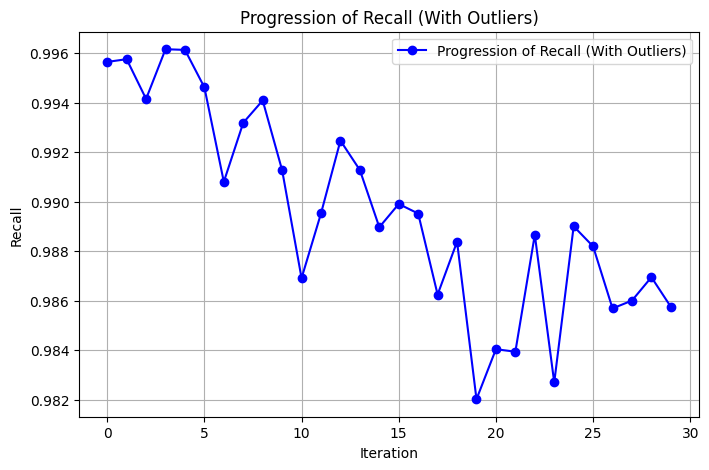

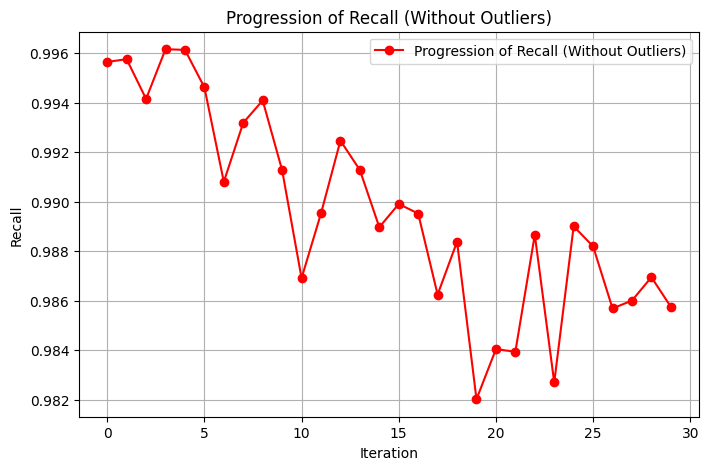

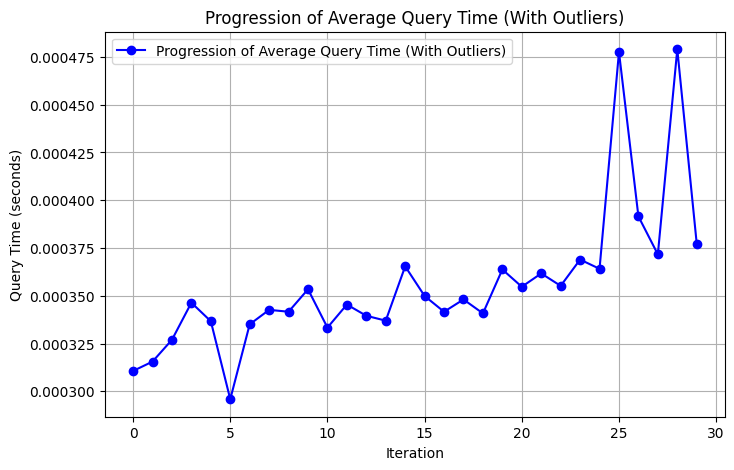

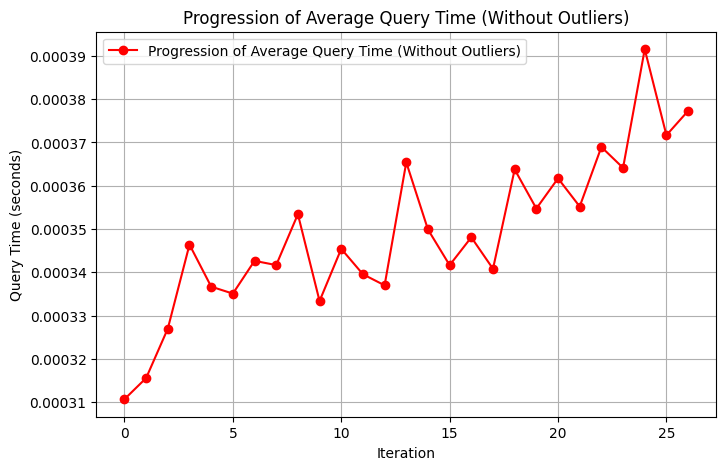

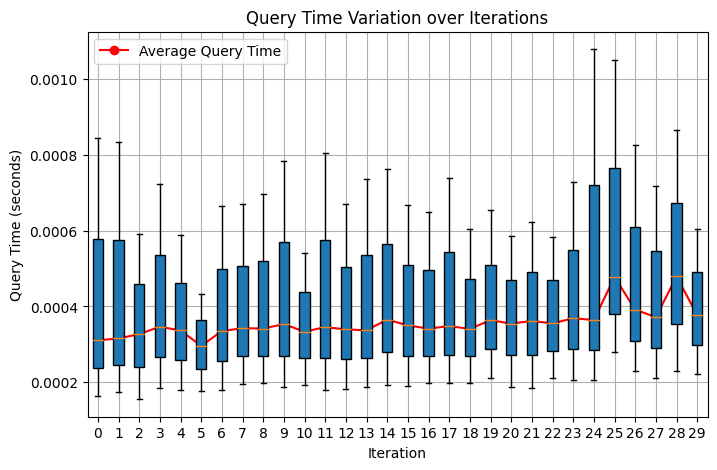

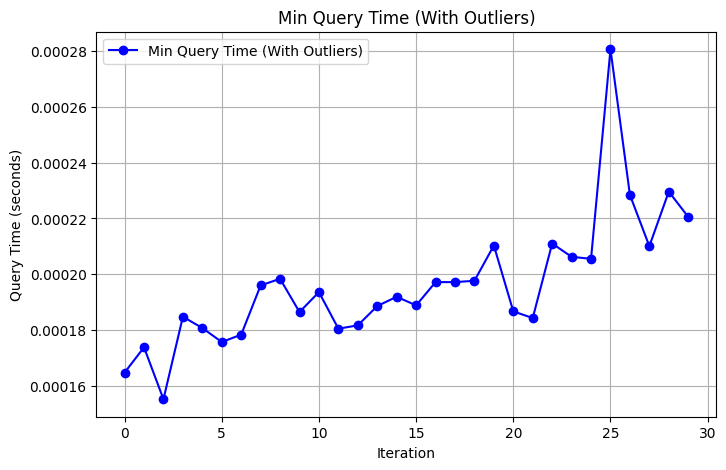

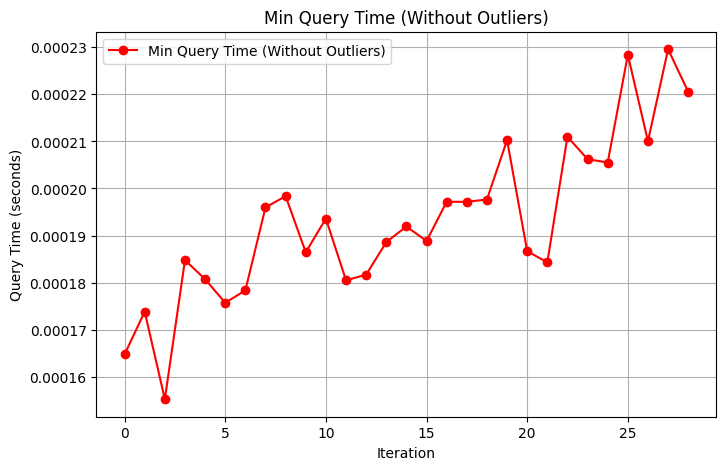

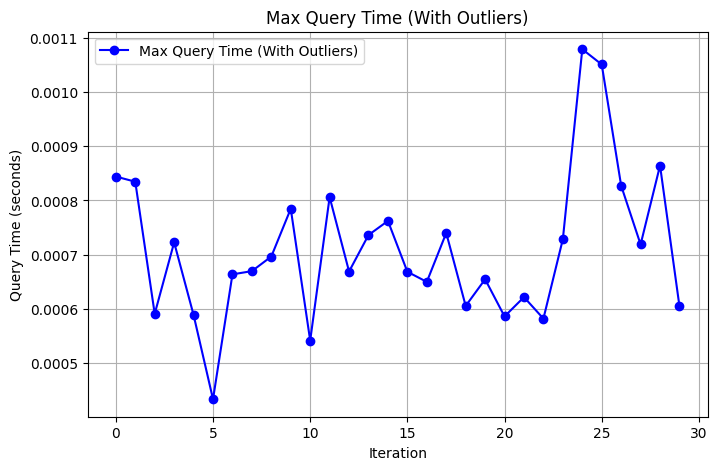

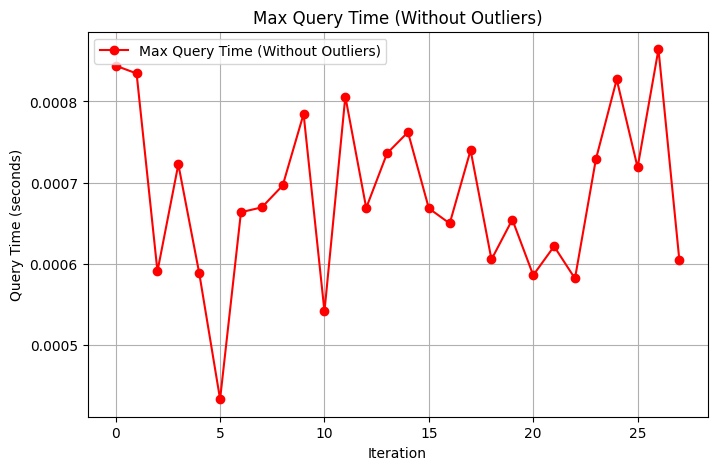

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

def load_data_from_json(file_path):
    with open(file_path, "r") as file:
        return json.load(file)

def remove_outliers(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return [x for x in data if lower_bound <= x <= upper_bound]

def plot_metric(x_values, y_values, ylabel, title, show_outliers=True):
    plt.figure(figsize=(8, 5))
    label = "With Outliers" if show_outliers else "Without Outliers"
    color = "blue" if show_outliers else "red"

    plt.plot(x_values, y_values, marker='o', linestyle='-', color=color, label=f"{title} ({label})")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(f"{title} ({label})")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_recall_and_query_time_variation(file_path):
    data = load_data_from_json(file_path)
    
    iterations = [entry["iteration"] for entry in data]
    recalls = [entry["recall_after_reinsertion"] for entry in data]
    avg_query_times = [entry["average_query_time"] for entry in data]
    min_query_times = [entry["min_query_time"] for entry in data]
    max_query_times = [entry["max_query_time"] for entry in data]

    filtered_recalls = remove_outliers(recalls)
    filtered_avg_query_times = remove_outliers(avg_query_times)
    filtered_min_query_times = remove_outliers(min_query_times)
    filtered_max_query_times = remove_outliers(max_query_times)

    plot_metric(iterations, recalls, "Recall", "Progression of Recall", show_outliers=True)
    plot_metric(iterations[:len(filtered_recalls)], filtered_recalls, "Recall", "Progression of Recall", show_outliers=False)

    plot_metric(iterations, avg_query_times, "Query Time (seconds)", "Progression of Average Query Time", show_outliers=True)
    plot_metric(iterations[:len(filtered_avg_query_times)], filtered_avg_query_times, "Query Time (seconds)", "Progression of Average Query Time", show_outliers=False)


    query_time_variation = [ 
        [min_t, avg_t, max_t] for min_t, avg_t, max_t in zip(min_query_times, avg_query_times, max_query_times)
    ]

    plt.figure(figsize=(8, 5))
    plt.boxplot(query_time_variation, positions=iterations, widths=0.5, patch_artist=True, showfliers=False)
    plt.plot(iterations, avg_query_times, marker='o', linestyle='-', color='red', label="Average Query Time")

    plt.xlabel("Iteration")
    plt.ylabel("Query Time (seconds)")
    plt.title("Query Time Variation over Iterations")
    plt.grid(True)
    plt.legend()
    plt.show()


    plot_metric(iterations, min_query_times, "Query Time (seconds)", "Min Query Time", show_outliers=True)
    plot_metric(iterations[:len(filtered_min_query_times)], filtered_min_query_times, "Query Time (seconds)", "Min Query Time", show_outliers=False)

    plot_metric(iterations, max_query_times, "Query Time (seconds)", "Max Query Time", show_outliers=True)
    plot_metric(iterations[:len(filtered_max_query_times)], filtered_max_query_times, "Query Time (seconds)", "Max Query Time", show_outliers=False)

plot_recall_and_query_time_variation("hnsw_mnist_same_size_index.json")

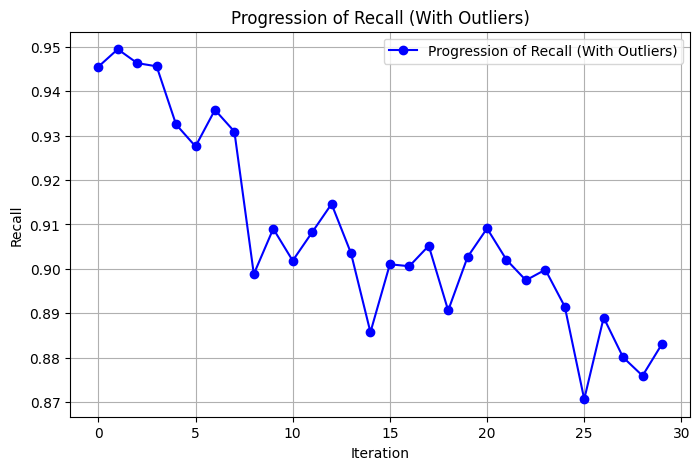

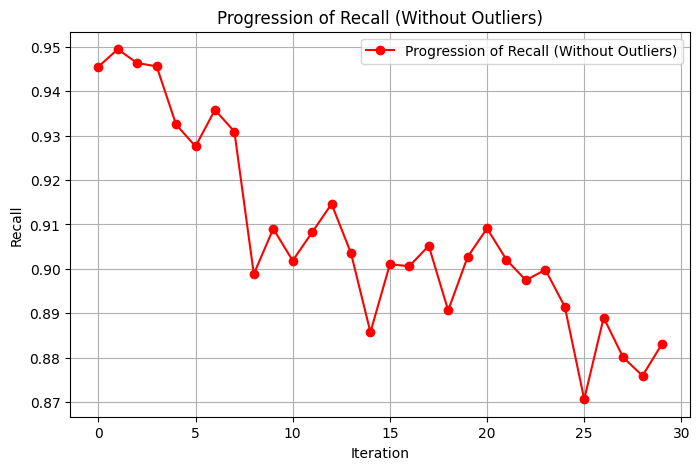

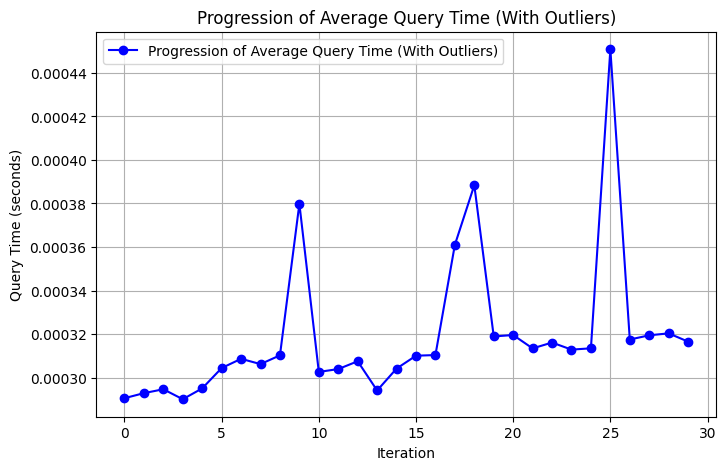

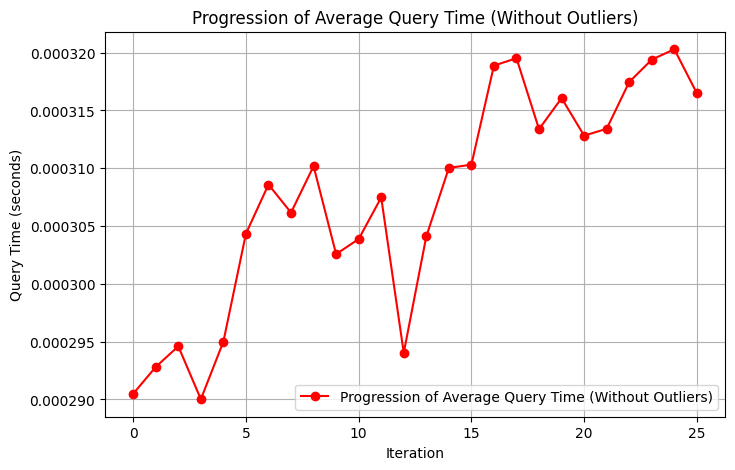

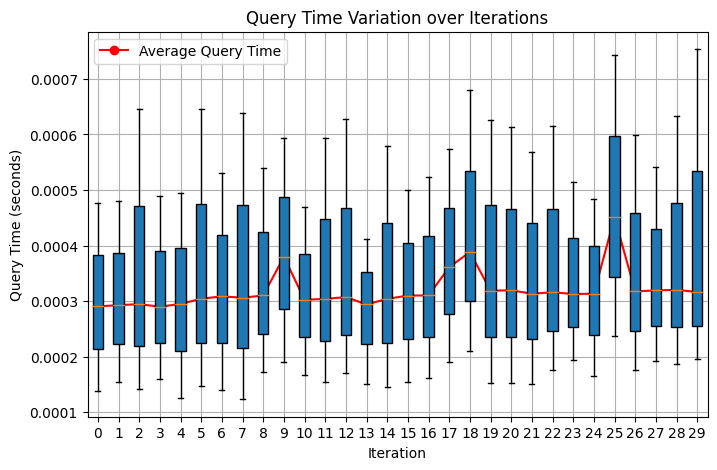

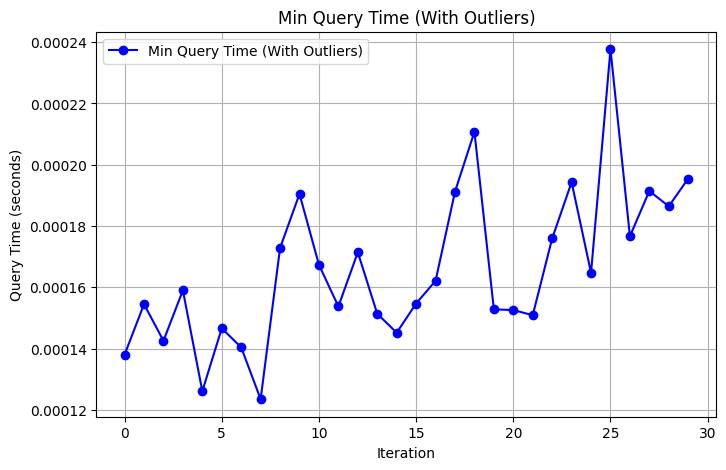

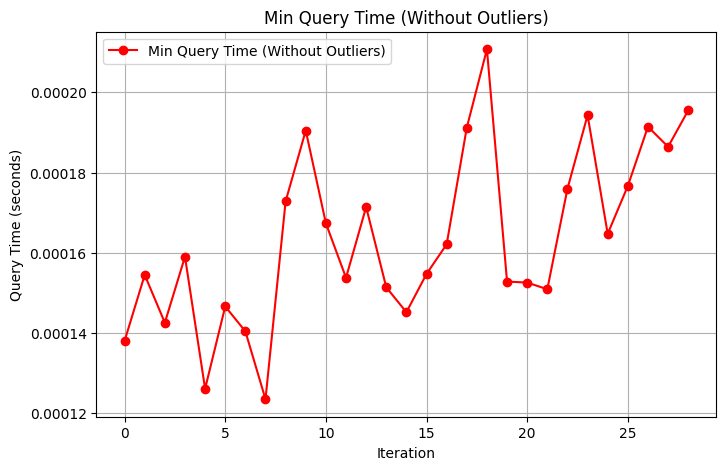

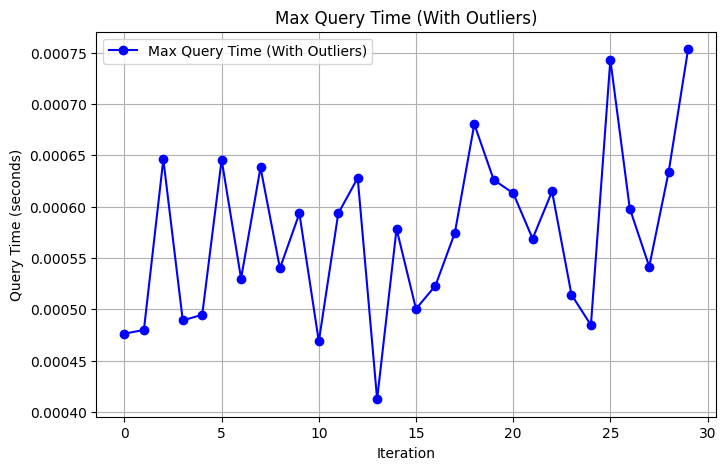

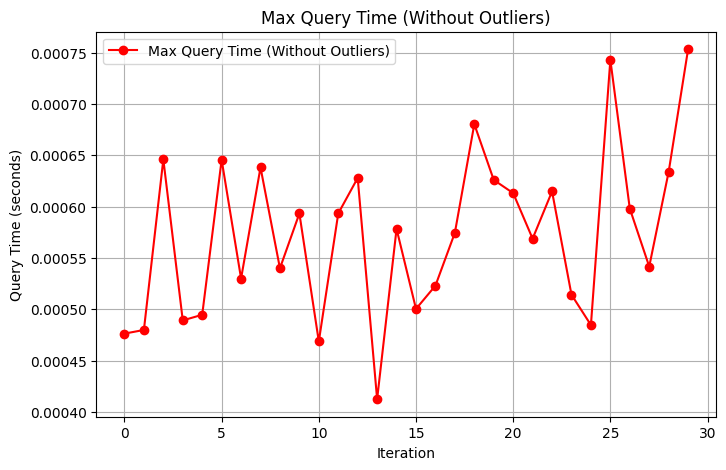

In [7]:
plot_recall_and_query_time_variation("hnsw_sift_same_size_index.json")
